In [1]:
from __future__ import print_function
import os
import sys

# Temporary workaround for Windows OpenMP duplicate runtime initialization in notebooks.
# Must be set before importing torch/torchvision/numpy-linked libraries.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

# Set up absolute path to the root of the project for importing custom modules.
sys.path.append(os.path.abspath("../.."))

# Import necessary torch libraries
import torch
import torch.optim as optim
import torchvision.transforms as transforms

# Import Model
from models.RESNET.RESNET_c import ResNet, ResidualBlock

# Import utils
from utils.train_val_utils import train_and_evaluate
from utils.dataloader_utils import dataloader
from utils.display_image_utils import display_original_vs_augmented
from utils.show_best_model_utils import show_best_model
from utils.load_best_model_utils import load_best_model
from utils.retrieve_results_from_ckpt_utils import results_from_ckpt
from utils.plot_train_val_curve_utils import plot_training_curves

# Set random seed for reproducibility
torch.manual_seed(42)

In [2]:
use_cuda = True
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if (use_cuda and torch.cuda.is_available()) else "cpu")
print(f"Using device: {device}")

CUDA available: True
Using device: cuda


In [3]:
# Tensor conversion
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load datasets and dataloaders without augmentation for training dataset
train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader = dataloader(
    train_root="../../butterfly_anomaly_image_resized/final_dataset/train",
    val_root="../../butterfly_anomaly_image_resized/final_dataset/val",
    test_root="../../butterfly_anomaly_image_resized/final_dataset/test",
    transform_train=transform,
    transform_eval=transform,
    batch_size=32,
    num_workers=4
)

Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 3538
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 442
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 444


Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 3538
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 442
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 444


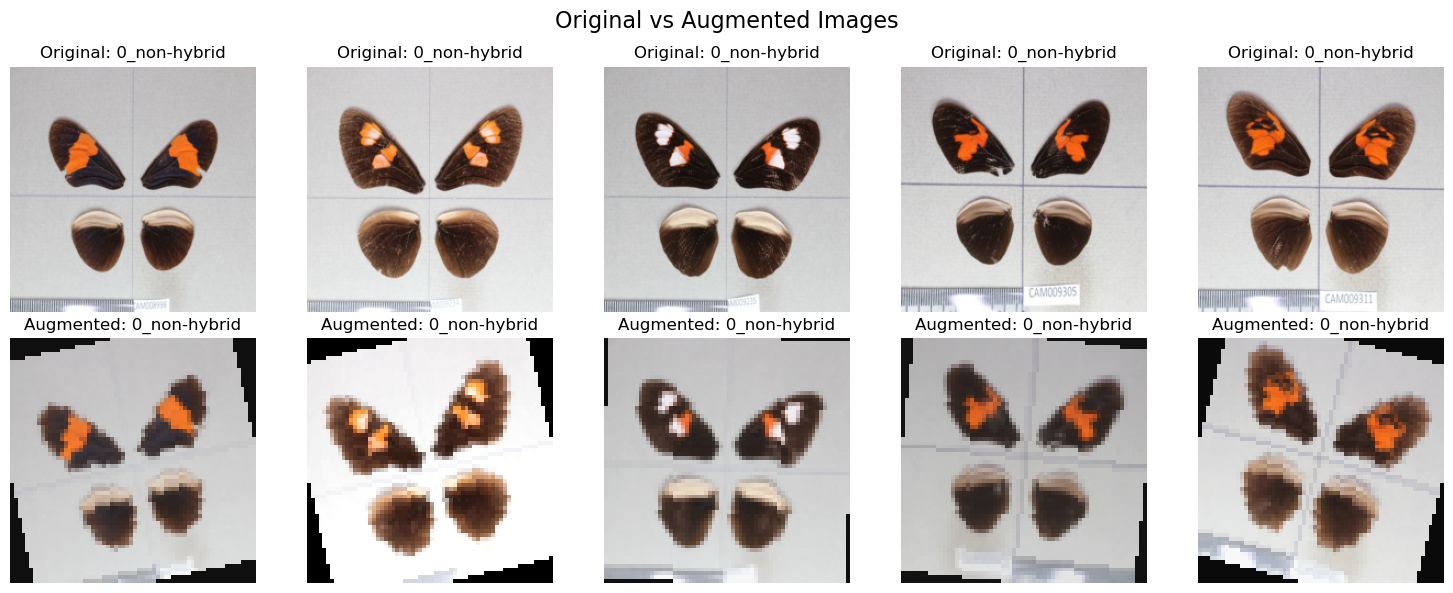

In [4]:
# Data augmentation transforms for training dataset
transform_train = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

# Data augmentation transforms for validation and test datasets (only resizing and tensor conversion)
transform_eval = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

# Load datasets and dataloaders with augmentation for training dataset
train_dataset_aug, val_dataset, test_dataset, train_loader_aug, val_loader, test_loader = dataloader(
    train_root="../../butterfly_anomaly_image_resized/final_dataset/train",
    val_root="../../butterfly_anomaly_image_resized/final_dataset/val",
    test_root="../../butterfly_anomaly_image_resized/final_dataset/test",
    transform_train=transform_train,
    transform_eval=transform_eval,
    batch_size=32,
    num_workers=4
)

assert train_dataset_aug.class_to_idx == val_dataset.class_to_idx == test_dataset.class_to_idx

display_original_vs_augmented(train_dataset, train_dataset_aug)

In [ ]:
learning_rate_values = [0.01, 0.005, 0.001, 0.0001]
weight_decay_values = [1e-3, 1e-4, 1e-5, 1e-6]
class_weights_values = [2.5, 3.5, 4.5, 5.5]
batch_size_values = [16, 32, 64, 128]
layer_configurations = [[2, 2, 2], [3, 2, 2], [3, 3, 3], [4, 3, 3]]

model_resnet_c_dict = {}
optimizer_c_dict = {}
results_c_dict = {}
best_c_dict = {}
best_f2_c_dict = {}

count = 1

best_learning_rate_dict = {}
best_weight_decay_dict = {}
best_class_weights_val_dict = {}
best_batch_size_dict = {}
best_layer_configuration_dict = {}

best_learning_rate = 0.01
best_weight_decay = 1e-3
best_class_weights_val = 2.5
best_batch_size = 16
best_layer_configuration = [2, 2, 2]

best_f2 = float("-inf")

# Hyperparameter tuning for learning rate
for learning_rate in learning_rate_values:
    model_resnet_c_dict[f"model_resnet_c{count}"] = ResNet(ResidualBlock, best_layer_configuration, num_classes=2).to(device)
    optimizer_c_dict[f"optimizer_c{count}"] = optim.Adam(model_resnet_c_dict[f"model_resnet_c{count}"].parameters(), lr=learning_rate, weight_decay=best_weight_decay)
    print(f"\nTraining RESNET Model C{count} with learning rate {learning_rate}")
    results_c_dict[f"results_c{count}"] = train_and_evaluate(model_resnet_c_dict[f"model_resnet_c{count}"], train_dataset_aug, val_dataset, optimizer_c_dict[f"optimizer_c{count}"], num_epochs=30, batch_size=best_batch_size, class_weights_val=best_class_weights_val, ckpt_file=f"../../saved_models/resnet/resnet_c/resnet_model_c{count}_log.pkl", device=device, num_workers=0)
    best_c_dict[f"best_c{count}"], best_f2_c_dict[f"best_f2_c{count}"] = show_best_model(model_resnet_c_dict[f"model_resnet_c{count}"], ckpt_file=f"../../saved_models/resnet/resnet_c/resnet_model_c{count}_log.pkl")
    best_learning_rate_dict[f"best_learning_rate_c{count}"] = learning_rate
    best_weight_decay_dict[f"best_weight_decay_c{count}"] = best_weight_decay
    best_class_weights_val_dict[f"best_class_weights_val_c{count}"] = best_class_weights_val
    best_batch_size_dict[f"best_batch_size_c{count}"] = best_batch_size
    best_layer_configuration_dict[f"best_layer_configuration_c{count}"] = best_layer_configuration
    count += 1
    if best_f2_c_dict[f"best_f2_c{count-1}"] > best_f2:
        best_learning_rate = learning_rate
        best_f2 = best_f2_c_dict[f"best_f2_c{count-1}"]

# Hyperparameter tuning for weight decay
for weight_decay in weight_decay_values[1:]:
    model_resnet_c_dict[f"model_resnet_c{count}"] = ResNet(ResidualBlock, best_layer_configuration, num_classes=2).to(device)
    optimizer_c_dict[f"optimizer_c{count}"] = optim.Adam(model_resnet_c_dict[f"model_resnet_c{count}"].parameters(), lr=best_learning_rate, weight_decay=weight_decay)
    print(f"\nTraining RESNET Model C{count} with weight decay {weight_decay}")
    results_c_dict[f"results_c{count}"] = train_and_evaluate(model_resnet_c_dict[f"model_resnet_c{count}"], train_dataset_aug, val_dataset, optimizer_c_dict[f"optimizer_c{count}"], num_epochs=30, batch_size=best_batch_size, class_weights_val=best_class_weights_val, ckpt_file=f"../../saved_models/resnet/resnet_c/resnet_model_c{count}_log.pkl", device=device, num_workers=0)
    best_c_dict[f"best_c{count}"], best_f2_c_dict[f"best_f2_c{count}"] = show_best_model(model_resnet_c_dict[f"model_resnet_c{count}"], ckpt_file=f"../../saved_models/resnet/resnet_c/resnet_model_c{count}_log.pkl")
    best_learning_rate_dict[f"best_learning_rate_c{count}"] = best_learning_rate
    best_weight_decay_dict[f"best_weight_decay_c{count}"] = weight_decay
    best_class_weights_val_dict[f"best_class_weights_val_c{count}"] = best_class_weights_val
    best_batch_size_dict[f"best_batch_size_c{count}"] = best_batch_size
    best_layer_configuration_dict[f"best_layer_configuration_c{count}"] = best_layer_configuration
    count += 1
    if best_f2_c_dict[f"best_f2_c{count-1}"] > best_f2:
        best_weight_decay = weight_decay
        best_f2 = best_f2_c_dict[f"best_f2_c{count-1}"]

# Hyperparameter tuning for class weights
for class_weights_val in class_weights_values[1:]:
    model_resnet_c_dict[f"model_resnet_c{count}"] = ResNet(ResidualBlock, best_layer_configuration, num_classes=2).to(device)
    optimizer_c_dict[f"optimizer_c{count}"] = optim.Adam(model_resnet_c_dict[f"model_resnet_c{count}"].parameters(), lr=best_learning_rate, weight_decay=best_weight_decay)
    print(f"\nTraining RESNET Model C{count} with class weights {class_weights_val}")
    results_c_dict[f"results_c{count}"] = train_and_evaluate(model_resnet_c_dict[f"model_resnet_c{count}"], train_dataset_aug, val_dataset, optimizer_c_dict[f"optimizer_c{count}"], num_epochs=30, batch_size=best_batch_size, class_weights_val=class_weights_val, ckpt_file=f"../../saved_models/resnet/resnet_c/resnet_model_c{count}_log.pkl", device=device, num_workers=0)
    best_c_dict[f"best_c{count}"], best_f2_c_dict[f"best_f2_c{count}"] = show_best_model(model_resnet_c_dict[f"model_resnet_c{count}"], ckpt_file=f"../../saved_models/resnet/resnet_c/resnet_model_c{count}_log.pkl")
    best_learning_rate_dict[f"best_learning_rate_c{count}"] = best_learning_rate
    best_weight_decay_dict[f"best_weight_decay_c{count}"] = best_weight_decay
    best_class_weights_val_dict[f"best_class_weights_val_c{count}"] = class_weights_val
    best_batch_size_dict[f"best_batch_size_c{count}"] = best_batch_size
    best_layer_configuration_dict[f"best_layer_configuration_c{count}"] = best_layer_configuration
    count += 1
    if best_f2_c_dict[f"best_f2_c{count-1}"] > best_f2:
        best_class_weights_val = class_weights_val
        best_f2 = best_f2_c_dict[f"best_f2_c{count-1}"]

# Hyperparameter tuning for batch size
for batch_size in batch_size_values[1:]:
    model_resnet_c_dict[f"model_resnet_c{count}"] = ResNet(ResidualBlock, best_layer_configuration, num_classes=2).to(device)
    optimizer_c_dict[f"optimizer_c{count}"] = optim.Adam(model_resnet_c_dict[f"model_resnet_c{count}"].parameters(), lr=best_learning_rate, weight_decay=best_weight_decay)
    print(f"\nTraining RESNET Model C{count} with batch size {batch_size}")
    results_c_dict[f"results_c{count}"] = train_and_evaluate(model_resnet_c_dict[f"model_resnet_c{count}"], train_dataset_aug, val_dataset, optimizer_c_dict[f"optimizer_c{count}"], num_epochs=30, batch_size=batch_size, class_weights_val=best_class_weights_val, ckpt_file=f"../../saved_models/resnet/resnet_c/resnet_model_c{count}_log.pkl", device=device, num_workers=0)
    best_c_dict[f"best_c{count}"], best_f2_c_dict[f"best_f2_c{count}"] = show_best_model(model_resnet_c_dict[f"model_resnet_c{count}"], ckpt_file=f"../../saved_models/resnet/resnet_c/resnet_model_c{count}_log.pkl")
    best_learning_rate_dict[f"best_learning_rate_c{count}"] = best_learning_rate
    best_weight_decay_dict[f"best_weight_decay_c{count}"] = best_weight_decay
    best_class_weights_val_dict[f"best_class_weights_val_c{count}"] = best_class_weights_val
    best_batch_size_dict[f"best_batch_size_c{count}"] = batch_size
    best_layer_configuration_dict[f"best_layer_configuration_c{count}"] = best_layer_configuration
    count += 1
    if best_f2_c_dict[f"best_f2_c{count-1}"] > best_f2:
        best_batch_size = batch_size
        best_f2 = best_f2_c_dict[f"best_f2_c{count-1}"]

# Hyperparameter tuning for layer configuration
for layer_configuration in layer_configurations[1:]:
    model_resnet_c_dict[f"model_resnet_c{count}"] = ResNet(ResidualBlock, layer_configuration, num_classes=2).to(device)
    optimizer_c_dict[f"optimizer_c{count}"] = optim.Adam(model_resnet_c_dict[f"model_resnet_c{count}"].parameters(), lr=best_learning_rate, weight_decay=best_weight_decay)
    print(f"\nTraining RESNET Model C{count} with layer configuration {layer_configuration}")
    results_c_dict[f"results_c{count}"] = train_and_evaluate(model_resnet_c_dict[f"model_resnet_c{count}"], train_dataset_aug, val_dataset, optimizer_c_dict[f"optimizer_c{count}"], num_epochs=30, batch_size=best_batch_size, class_weights_val=best_class_weights_val, ckpt_file=f"saved_models/resnet/resnet_c/resnet_model_c{count}_log.pkl", device=device, num_workers=0)
    best_c_dict[f"best_c{count}"], best_f2_c_dict[f"best_f2_c{count}"] = show_best_model(model_resnet_c_dict[f"model_resnet_c{count}"], ckpt_file=f"../../saved_models/resnet/resnet_c/resnet_model_c{count}_log.pkl")
    best_learning_rate_dict[f"best_learning_rate_c{count}"] = best_learning_rate
    best_weight_decay_dict[f"best_weight_decay_c{count}"] = best_weight_decay
    best_class_weights_val_dict[f"best_class_weights_val_c{count}"] = best_class_weights_val
    best_batch_size_dict[f"best_batch_size_c{count}"] = best_batch_size
    best_layer_configuration_dict[f"best_layer_configuration_c{count}"] = layer_configuration
    count += 1
    if best_f2_c_dict[f"best_f2_c{count-1}"] > best_f2:
        best_layer_configuration = layer_configuration
        best_f2 = best_f2_c_dict[f"best_f2_c{count-1}"]


Training RESNET Model C1 with learning rate 0.01
  [Epoch 1] Improvement! New best score: 0.601093
  [Epoch 3] Improvement! New best score: 0.764840
  [Epoch 5] Improvement! New best score: 0.779817
Epoch [5/30], Train Loss: 0.3613, Val Loss: 0.4532, Train F1-Macro: 0.7523, Val F1-Macro: 0.7526, Train F1-Per-Class: [0.87929744 0.62529004], Val F1-Per-Class: [0.8785607 0.6267281], Train F2-Macro: 0.8015, Val F2-Macro: 0.8028, Train F2-Per-Class: [0.8277051 0.7753165], Val F2-Per-Class: [0.82581735 0.7798165 ], No improvement: 0/6
Epoch [5/30], Epoch [5/30], Train Loss: 0.3613, Val Loss: 0.4532, Train F1-Macro: 0.7523, Val F1-Macro: 0.7526, Train F1-Per-Class: [0.87929744 0.62529004], Val F1-Per-Class: [0.8785607 0.6267281] Train F2-Macro: 0.8015, Val F2-Macro: 0.8028, Train F2-Per-Class: [0.8277051 0.7753165], Val F2-Per-Class: [0.82581735 0.7798165 ]
  [Epoch 8] Improvement! New best score: 0.793839
Epoch [10/30], Train Loss: 0.3298, Val Loss: 0.2835, Train F1-Macro: 0.5076, Val F1-Ma

In [5]:
# Restore best hyperparameters for model_c
best_learning_rate_dict = {'best_learning_rate_c1': 0.01, 'best_learning_rate_c2': 0.005, 'best_learning_rate_c3': 0.001, 'best_learning_rate_c4': 0.0001, 'best_learning_rate_c5': 0.001, 'best_learning_rate_c6': 0.001, 'best_learning_rate_c7': 0.001, 'best_learning_rate_c8': 0.001, 'best_learning_rate_c9': 0.001, 'best_learning_rate_c10': 0.001, 'best_learning_rate_c11': 0.001, 'best_learning_rate_c12': 0.001, 'best_learning_rate_c13': 0.001, 'best_learning_rate_c14': 0.001, 'best_learning_rate_c15': 0.001, 'best_learning_rate_c16': 0.001}
best_weight_decay_dict = {'best_weight_decay_c1': 0.001, 'best_weight_decay_c2': 0.001, 'best_weight_decay_c3': 0.001, 'best_weight_decay_c4': 0.001, 'best_weight_decay_c5': 0.0001, 'best_weight_decay_c6': 1e-05, 'best_weight_decay_c7': 1e-06, 'best_weight_decay_c8': 1e-06, 'best_weight_decay_c9': 1e-06, 'best_weight_decay_c10': 1e-06, 'best_weight_decay_c11': 1e-06, 'best_weight_decay_c12': 1e-06, 'best_weight_decay_c13': 1e-06, 'best_weight_decay_c14': 1e-06, 'best_weight_decay_c15': 1e-06, 'best_weight_decay_c16': 1e-06}
best_class_weights_val_dict = {'best_class_weights_val_c1': 2.5, 'best_class_weights_val_c2': 2.5, 'best_class_weights_val_c3': 2.5, 'best_class_weights_val_c4': 2.5, 'best_class_weights_val_c5': 2.5, 'best_class_weights_val_c6': 2.5, 'best_class_weights_val_c7': 2.5, 'best_class_weights_val_c8': 3.5, 'best_class_weights_val_c9': 4.5, 'best_class_weights_val_c10': 5.5, 'best_class_weights_val_c11': 5.5, 'best_class_weights_val_c12': 5.5, 'best_class_weights_val_c13': 5.5, 'best_class_weights_val_c14': 5.5, 'best_class_weights_val_c15': 5.5, 'best_class_weights_val_c16': 5.5}
best_batch_size_dict = {'best_batch_size_c1': 16, 'best_batch_size_c2': 16, 'best_batch_size_c3': 16, 'best_batch_size_c4': 16, 'best_batch_size_c5': 16, 'best_batch_size_c6': 16, 'best_batch_size_c7': 16, 'best_batch_size_c8': 16, 'best_batch_size_c9': 16, 'best_batch_size_c10': 16, 'best_batch_size_c11': 32, 'best_batch_size_c12': 64, 'best_batch_size_c13': 128, 'best_batch_size_c14': 16, 'best_batch_size_c15': 16, 'best_batch_size_c16': 16}
best_layer_configuration_dict = {'best_layer_configuration_c1': [2, 2, 2], 'best_layer_configuration_c2': [2, 2, 2], 'best_layer_configuration_c3': [2, 2, 2], 'best_layer_configuration_c4': [2, 2, 2], 'best_layer_configuration_c5': [2, 2, 2], 'best_layer_configuration_c6': [2, 2, 2], 'best_layer_configuration_c7': [2, 2, 2], 'best_layer_configuration_c8': [2, 2, 2], 'best_layer_configuration_c9': [2, 2, 2], 'best_layer_configuration_c10': [2, 2, 2], 'best_layer_configuration_c11': [2, 2, 2], 'best_layer_configuration_c12': [2, 2, 2], 'best_layer_configuration_c13': [2, 2, 2], 'best_layer_configuration_c14': [3, 2, 2], 'best_layer_configuration_c15': [3, 3, 3], 'best_layer_configuration_c16': [4, 3, 3]}

# Initialize model_resnet_c_dict with ResNet instances for each hyperparameter combination
model_resnet_c_dict = {
    'model_resnet_c1': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_c2': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_c3': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_c4': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_c5': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_c6': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_c7': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_c8': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_c9': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_c10': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_c11': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_c12': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_c13': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_c14': ResNet(ResidualBlock, [3, 2, 2], num_classes=2).to(device),
    'model_resnet_c15': ResNet(ResidualBlock, [3, 3, 3], num_classes=2).to(device),
    'model_resnet_c16': ResNet(ResidualBlock, [4, 3, 3], num_classes=2).to(device)
}

best_c_dict = {}
best_f2_c_dict = {}

In [6]:
for i in range(1, 8):
    print(
        f"Model C{i} | "
        f"lr={best_learning_rate_dict[f'best_learning_rate_c{i}']} | "
        f"wd={best_weight_decay_dict[f'best_weight_decay_c{i}']} | "
        f"class_w={best_class_weights_val_dict[f'best_class_weights_val_c{i}']} | "
        f"bs={best_batch_size_dict[f'best_batch_size_c{i}']} | "
        f"layers={best_layer_configuration_dict[f'best_layer_configuration_c{i}']}"
    )
    best_c_dict[f"best_c{i}"], best_f2_c_dict[f"best_f2_c{i}"] = show_best_model(model=model_resnet_c_dict[f"model_resnet_c{i}"], ckpt_file=f"../../saved_models/resnet/resnet_c/resnet_model_c{i}_log.pkl")

Model C1 | lr=0.01 | wd=0.001 | class_w=2.5 | bs=16 | layers=[2, 2, 2]
Selected epoch: 12
Best val F2(class 0): 0.9218491911888123
Best val F2(class 1): 0.8524172902107239
Model C2 | lr=0.005 | wd=0.001 | class_w=2.5 | bs=16 | layers=[2, 2, 2]
Selected epoch: 8
Best val F2(class 0): 0.9684439897537231
Best val F2(class 1): 0.9005376100540161
Model C3 | lr=0.001 | wd=0.001 | class_w=2.5 | bs=16 | layers=[2, 2, 2]
Selected epoch: 12
Best val F2(class 0): 0.9744148254394531
Best val F2(class 1): 0.9383378028869629
Model C4 | lr=0.0001 | wd=0.001 | class_w=2.5 | bs=16 | layers=[2, 2, 2]
Selected epoch: 6
Best val F2(class 0): 0.9788503050804138
Best val F2(class 1): 0.9016393423080444
Model C5 | lr=0.001 | wd=0.0001 | class_w=2.5 | bs=16 | layers=[2, 2, 2]
Selected epoch: 15
Best val F2(class 0): 0.9749455451965332
Best val F2(class 1): 0.9491978883743286
Model C6 | lr=0.001 | wd=1e-05 | class_w=2.5 | bs=16 | layers=[2, 2, 2]
Selected epoch: 7
Best val F2(class 0): 0.980445384979248
Best v

In [8]:
for i in range(8, 15):
    print(
        f"Model C{i} | "
        f"lr={best_learning_rate_dict[f'best_learning_rate_c{i}']} | "
        f"wd={best_weight_decay_dict[f'best_weight_decay_c{i}']} | "
        f"class_w={best_class_weights_val_dict[f'best_class_weights_val_c{i}']} | "
        f"bs={best_batch_size_dict[f'best_batch_size_c{i}']} | "
        f"layers={best_layer_configuration_dict[f'best_layer_configuration_c{i}']}"
    )
    best_c_dict[f"best_c{i}"], best_f2_c_dict[f"best_f2_c{i}"] = show_best_model(model=model_resnet_c_dict[f"model_resnet_c{i}"], ckpt_file=f"../../saved_models/resnet/resnet_c/resnet_model_c{i}_log.pkl")

Model C8 | lr=0.001 | wd=1e-06 | class_w=3.5 | bs=16 | layers=[2, 2, 2]
Selected epoch: 16
Best val F2(class 0): 0.98097825050354
Best val F2(class 1): 0.9459459185600281
Model C9 | lr=0.001 | wd=1e-06 | class_w=4.5 | bs=16 | layers=[2, 2, 2]
Selected epoch: 22
Best val F2(class 0): 0.9815117120742798
Best val F2(class 1): 0.9568732976913452
Model C10 | lr=0.001 | wd=1e-06 | class_w=5.5 | bs=16 | layers=[2, 2, 2]
Selected epoch: 12
Best val F2(class 0): 0.977668821811676
Best val F2(class 1): 0.9625668525695801
Model C11 | lr=0.001 | wd=1e-06 | class_w=5.5 | bs=32 | layers=[2, 2, 2]
Selected epoch: 3
Best val F2(class 0): 0.956807017326355
Best val F2(class 1): 0.9186351895332336
Model C12 | lr=0.001 | wd=1e-06 | class_w=5.5 | bs=64 | layers=[2, 2, 2]
Selected epoch: 13
Best val F2(class 0): 0.9700272679328918
Best val F2(class 1): 0.9333333373069763
Model C13 | lr=0.001 | wd=1e-06 | class_w=5.5 | bs=128 | layers=[2, 2, 2]
Selected epoch: 13
Best val F2(class 0): 0.9590163826942444
Bes

In [9]:
for i in range(15, 17):
    print(
        f"Model C{i} | "
        f"lr={best_learning_rate_dict[f'best_learning_rate_c{i}']} | "
        f"wd={best_weight_decay_dict[f'best_weight_decay_c{i}']} | "
        f"class_w={best_class_weights_val_dict[f'best_class_weights_val_c{i}']} | "
        f"bs={best_batch_size_dict[f'best_batch_size_c{i}']} | "
        f"layers={best_layer_configuration_dict[f'best_layer_configuration_c{i}']}"
    )
    best_c_dict[f"best_c{i}"], best_f2_c_dict[f"best_f2_c{i}"] = show_best_model(model=model_resnet_c_dict[f"model_resnet_c{i}"], ckpt_file=f"../../saved_models/resnet/resnet_c/resnet_model_c{i}_log.pkl")

Model C15 | lr=0.001 | wd=1e-06 | class_w=5.5 | bs=16 | layers=[3, 3, 3]
Selected epoch: 10
Best val F2(class 0): 0.9886240363121033
Best val F2(class 1): 0.9340659379959106
Model C16 | lr=0.001 | wd=1e-06 | class_w=5.5 | bs=16 | layers=[4, 3, 3]
Selected epoch: 10
Best val F2(class 0): 0.9683578610420227
Best val F2(class 1): 0.941644549369812


In [10]:
# Pick the model index with highest validation F2 (class 1) among all collected runs
best_f2_key = max(best_f2_c_dict, key=lambda k: float(best_f2_c_dict[k]))
best_i = int(best_f2_key.split("c")[-1])

model = model_resnet_c_dict[f"model_resnet_c{best_i}"]
best = best_c_dict[f"best_c{best_i}"]

print(
    f"Selected Best Model C{best_i} | "
    f"val_f2_class1={float(best_f2_c_dict[best_f2_key]):.6f} | "
    f"lr={best_learning_rate_dict[f'best_learning_rate_c{best_i}']} | "
    f"wd={best_weight_decay_dict[f'best_weight_decay_c{best_i}']} | "
    f"class_w={best_class_weights_val_dict[f'best_class_weights_val_c{best_i}']} | "
    f"bs={best_batch_size_dict[f'best_batch_size_c{best_i}']} | "
    f"layers={best_layer_configuration_dict[f'best_layer_configuration_c{best_i}']}"
)

# Load the best model and evaluate on the test dataset
load_best_model(best_model=model, best=best, test_dataset=test_dataset, device=device)

Selected Best Model C10 | val_f2_class1=0.962567 | lr=0.001 | wd=1e-06 | class_w=5.5 | bs=16 | layers=[2, 2, 2]
Test loss: 0.09778611634439065
Test F2 macro: 0.9488478899002075
Test F2 per class: [0.9717698 0.9259259]
Test F2 for class 1 (1_hybrid): 0.9259259104728699


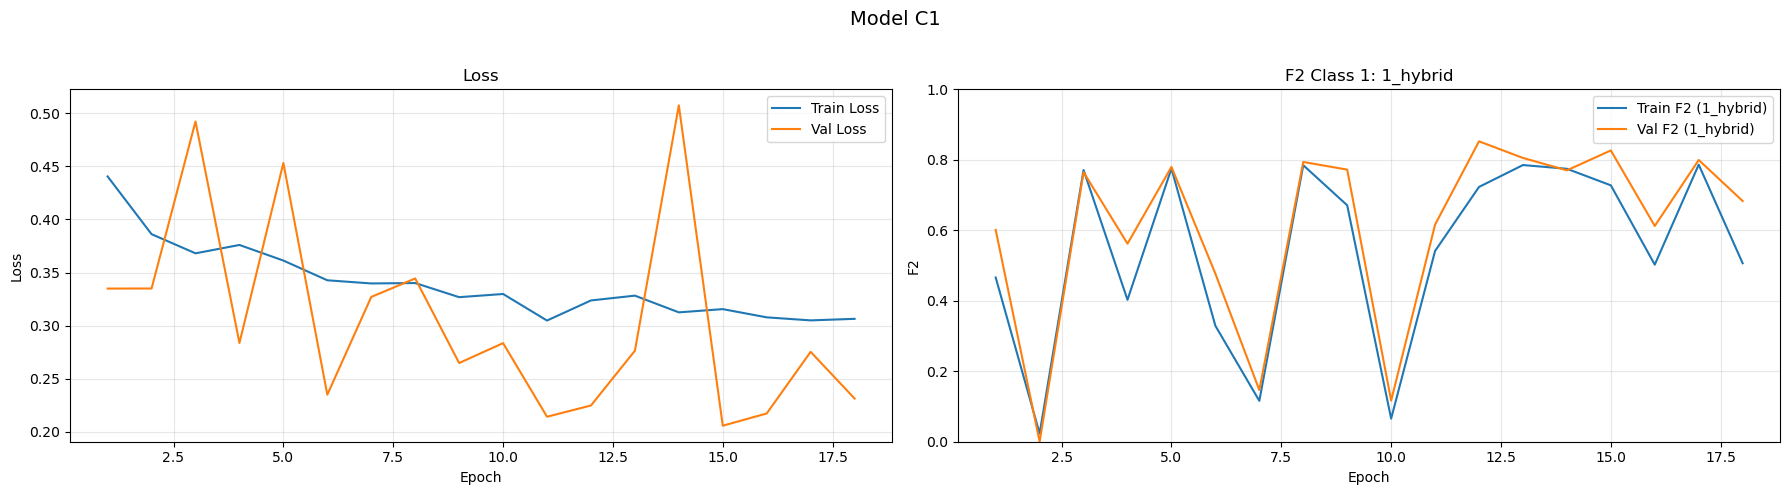

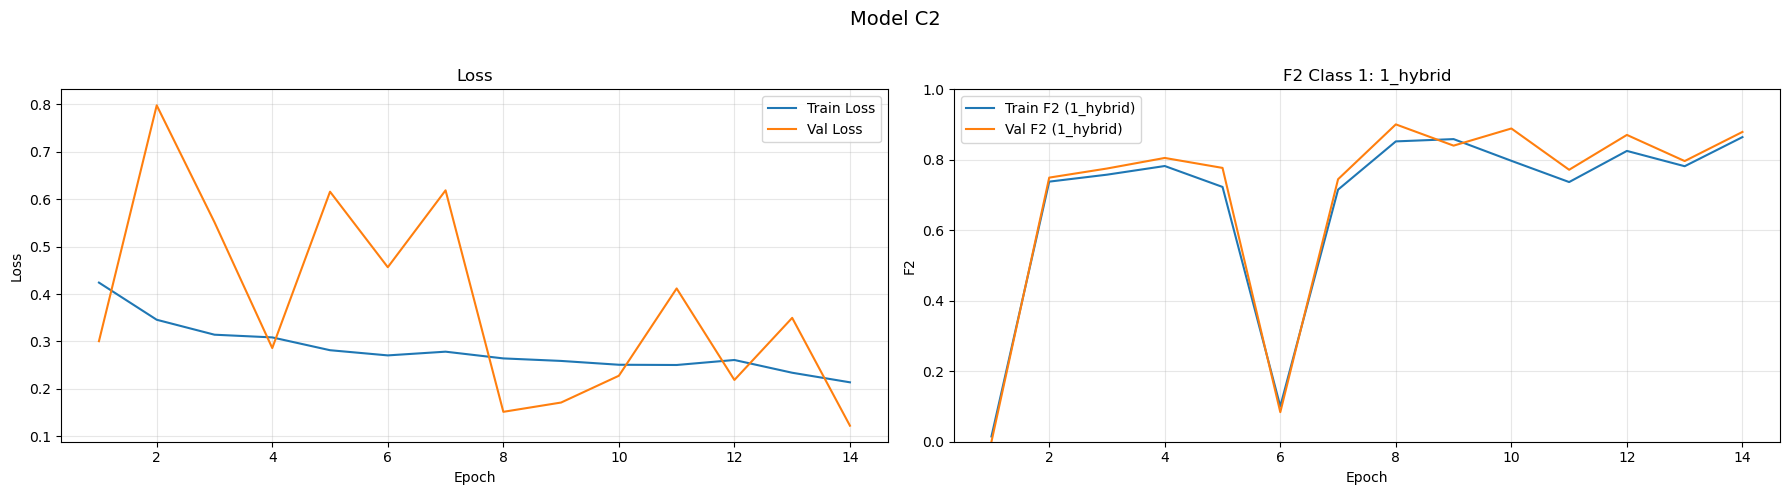

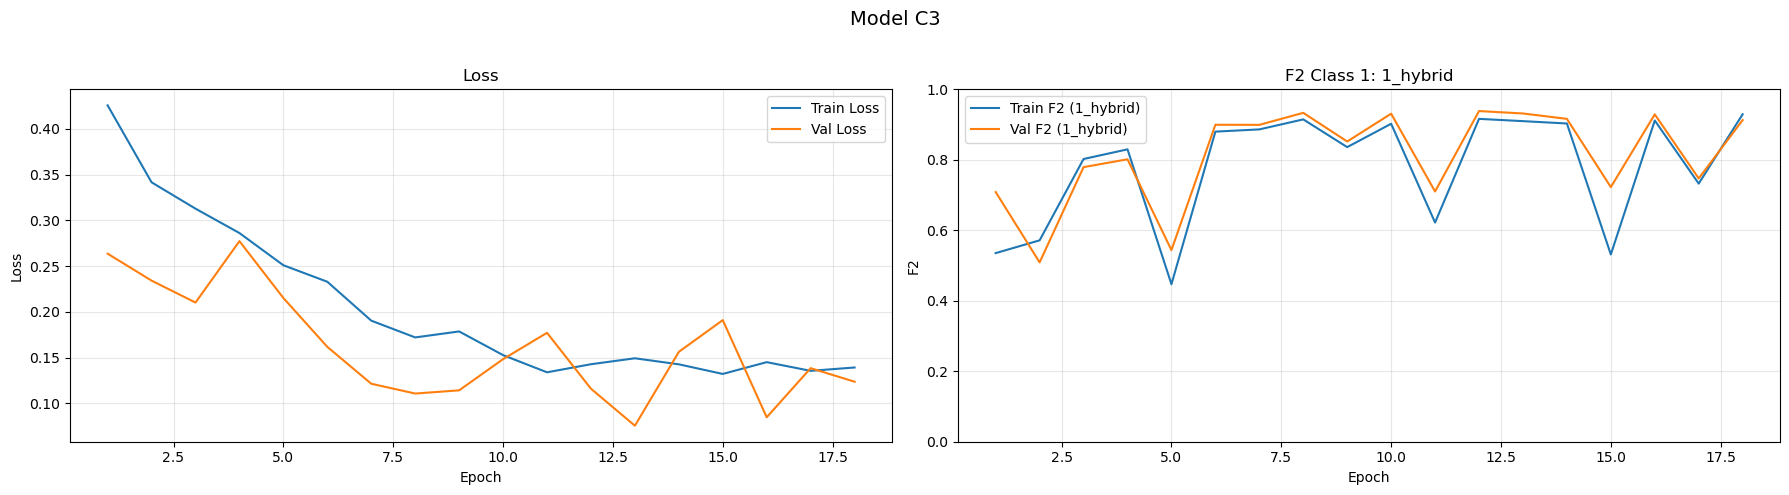

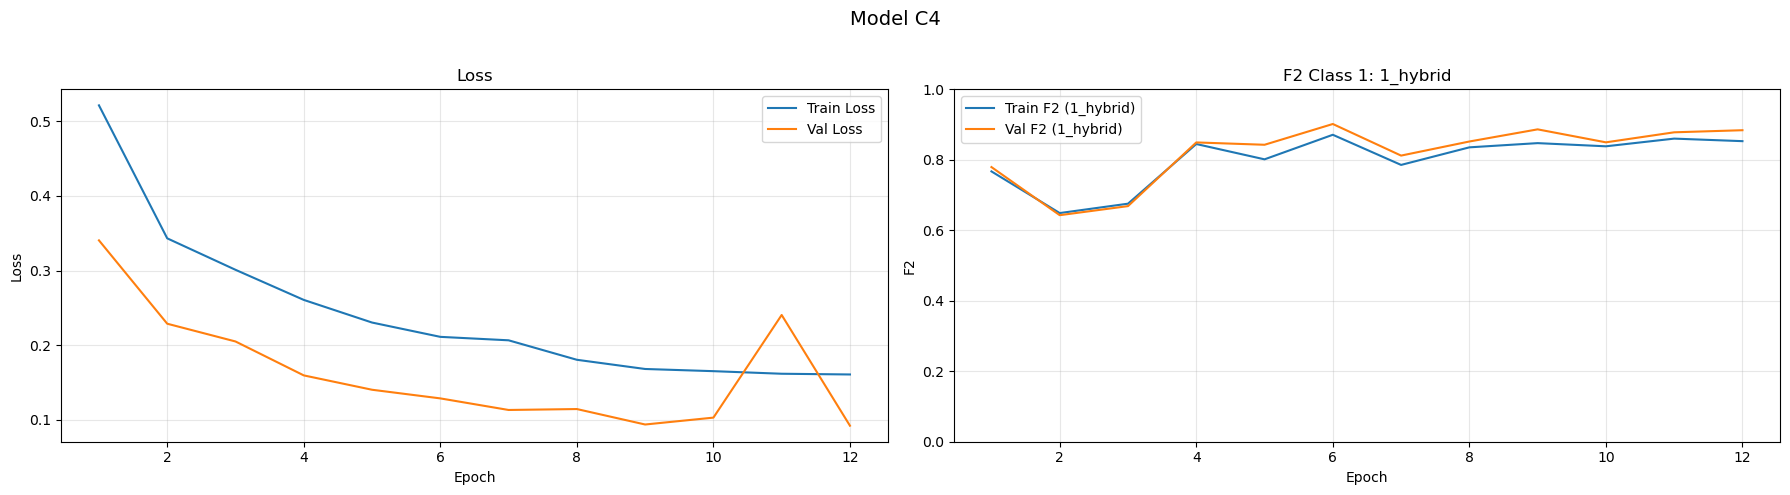

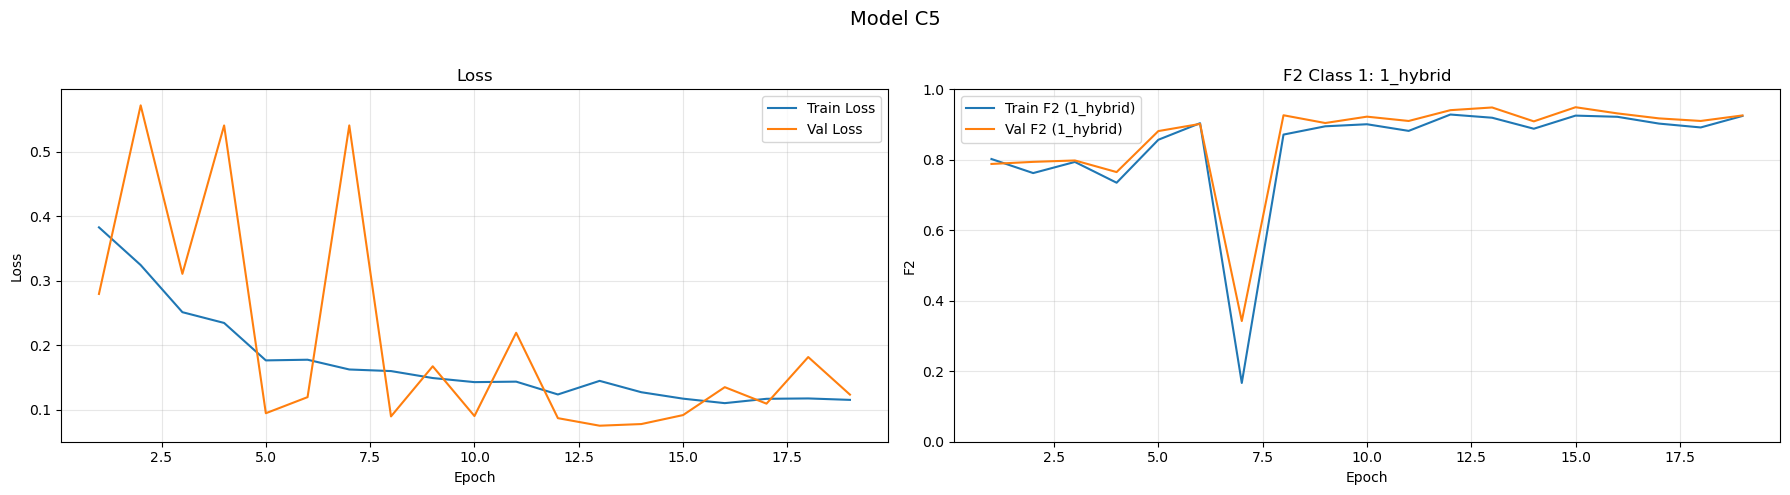

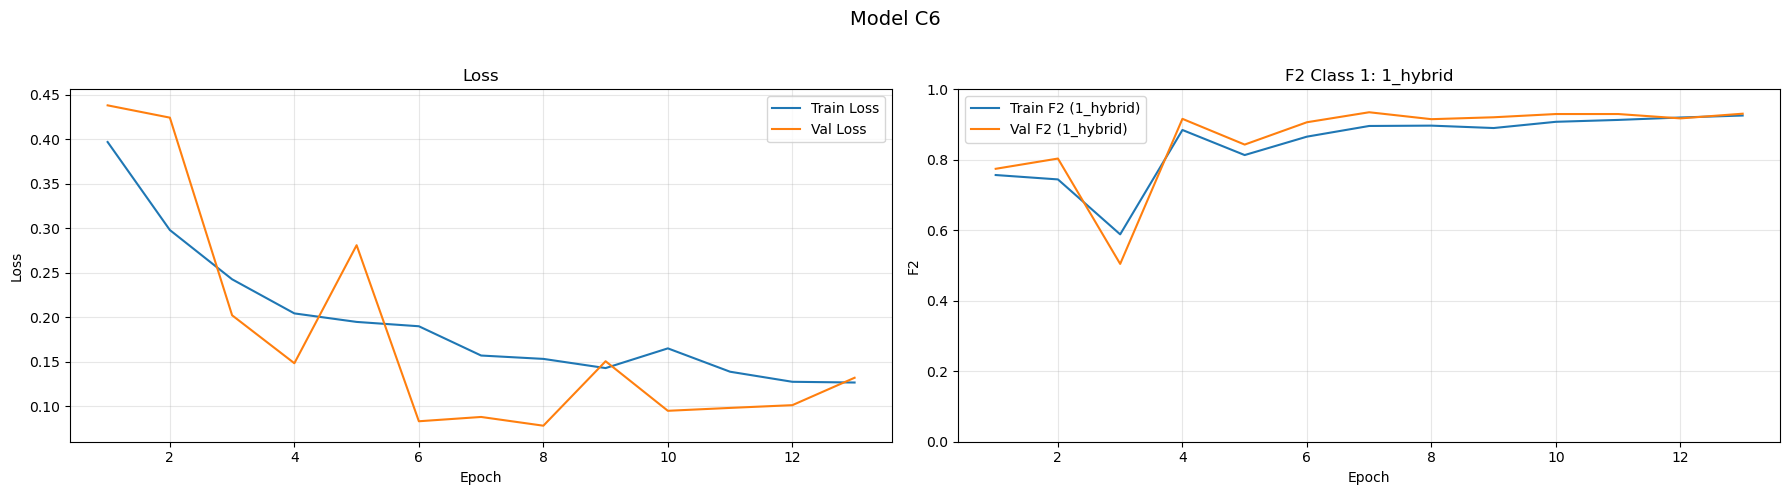

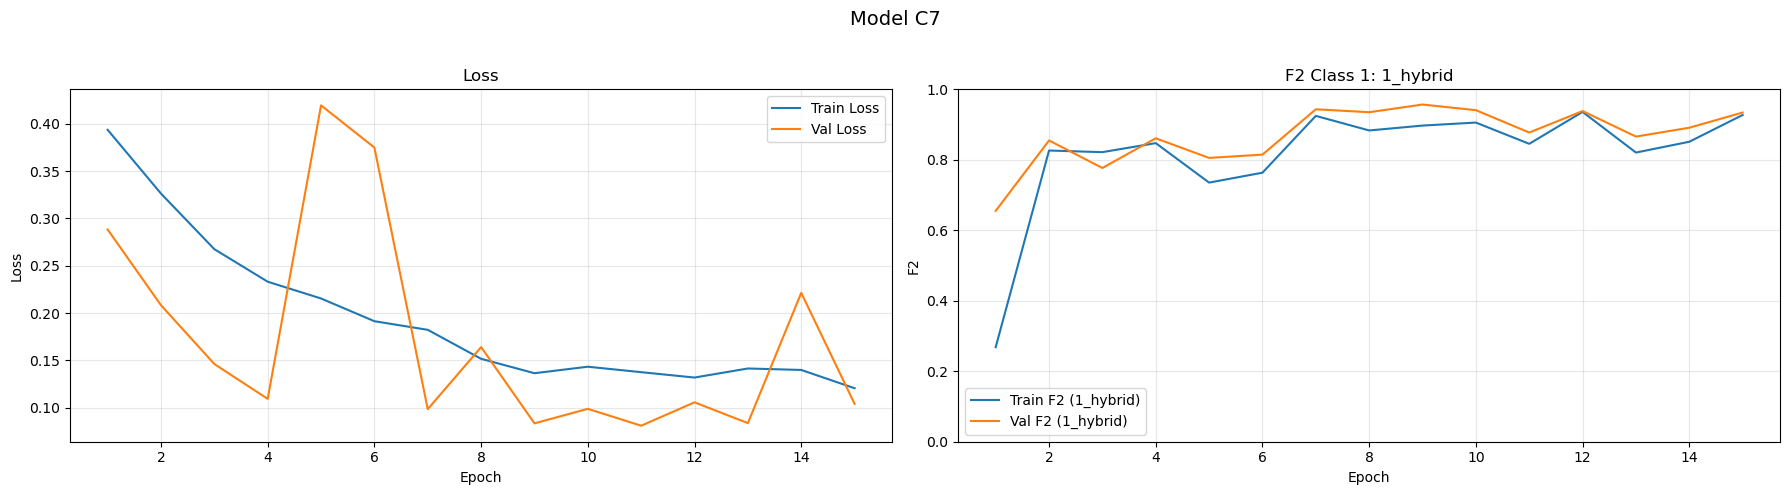

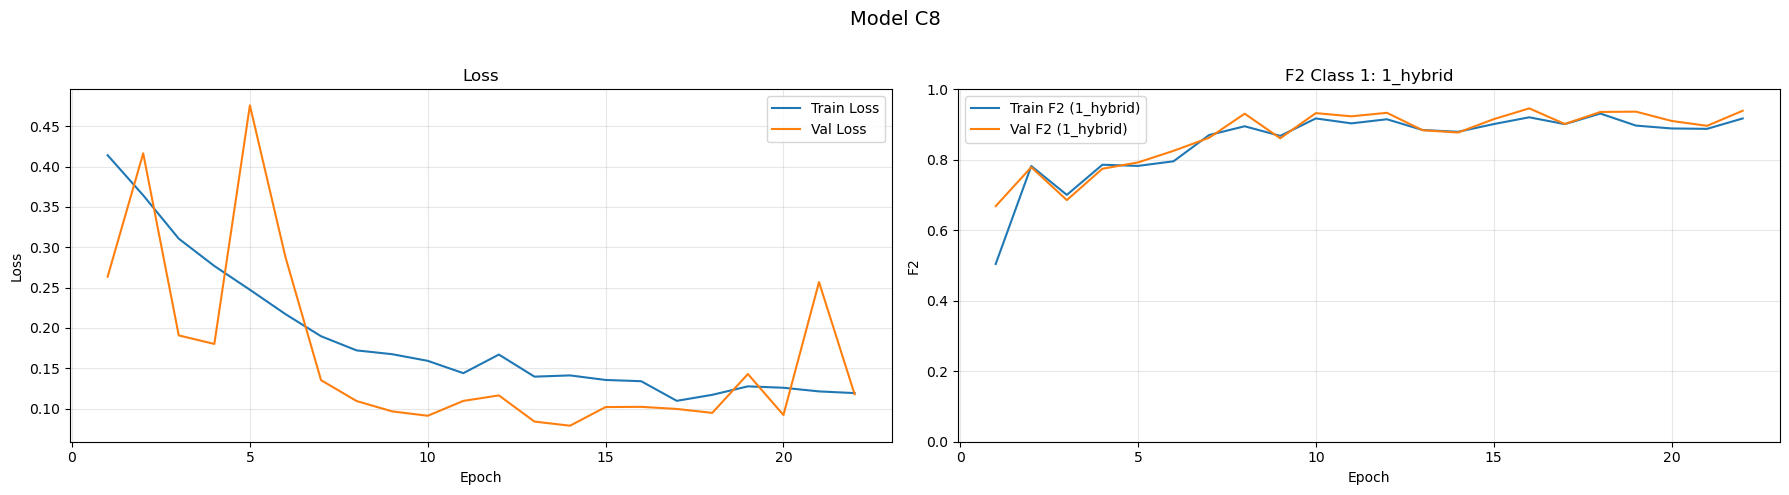

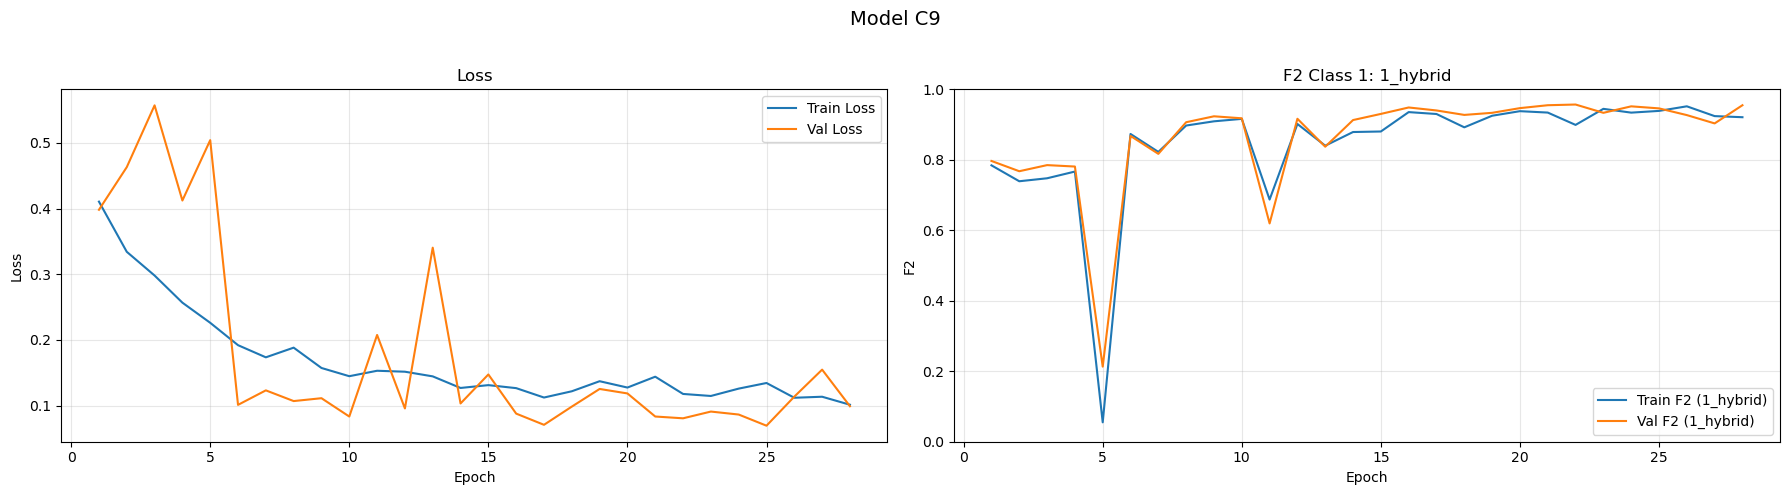

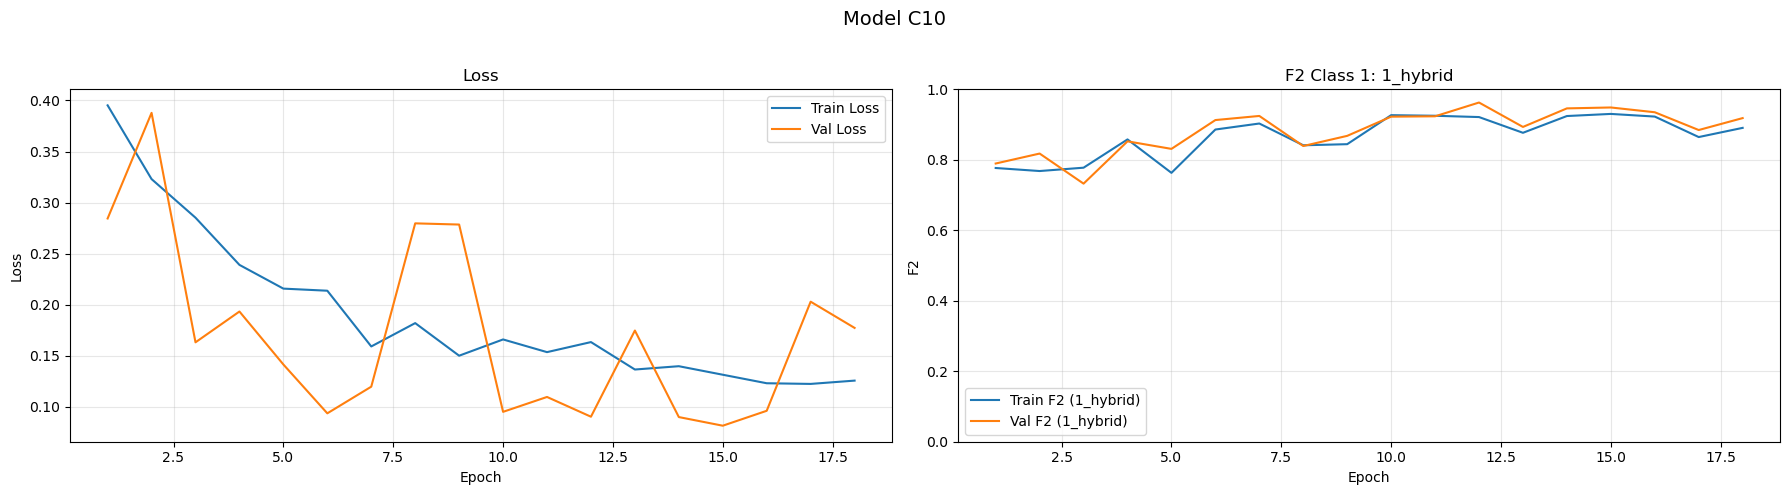

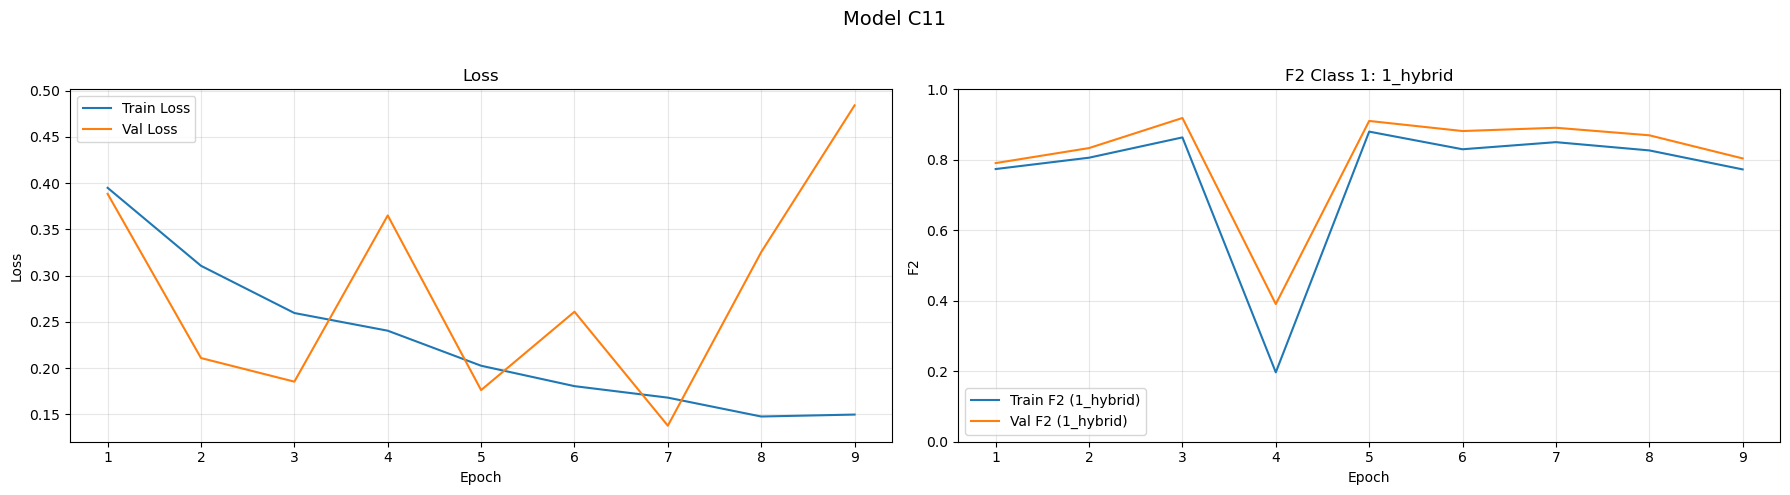

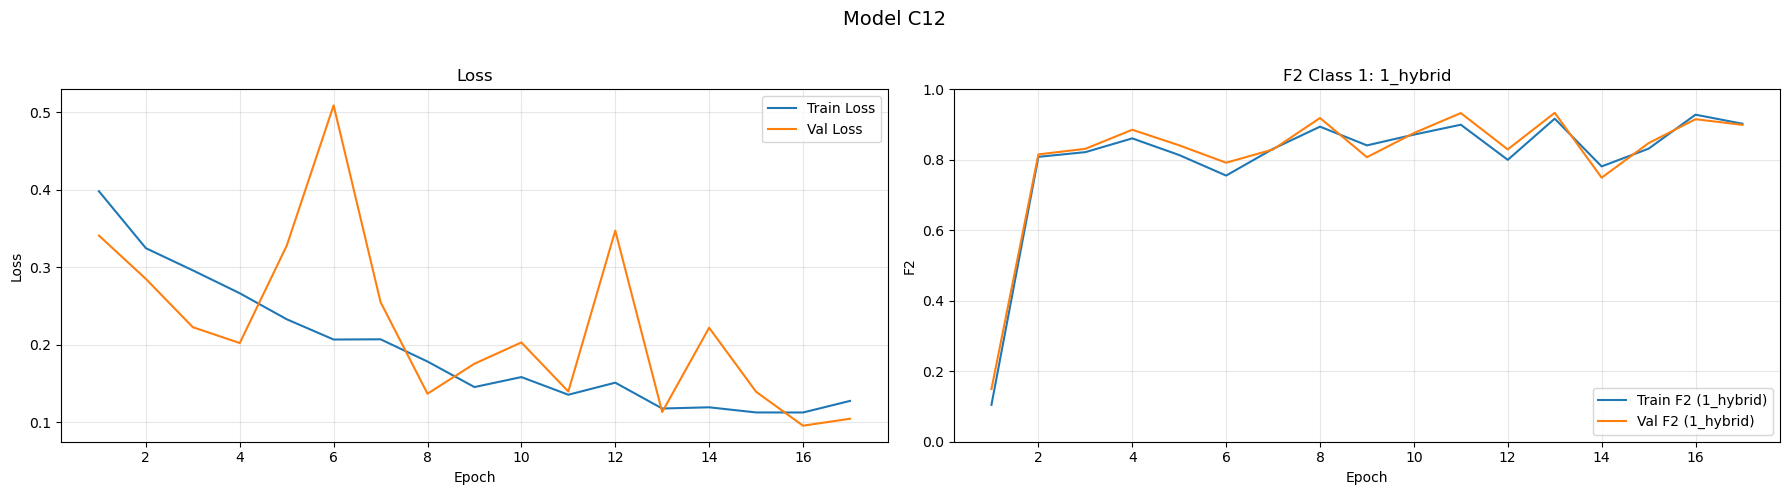

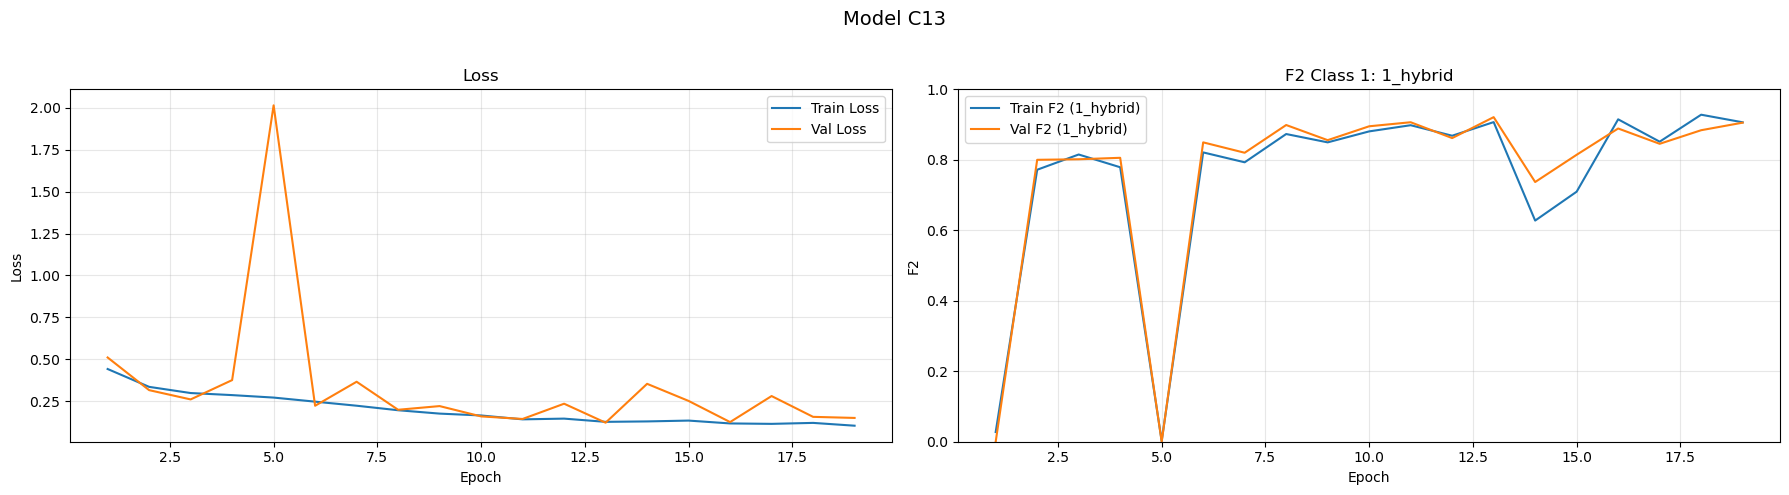

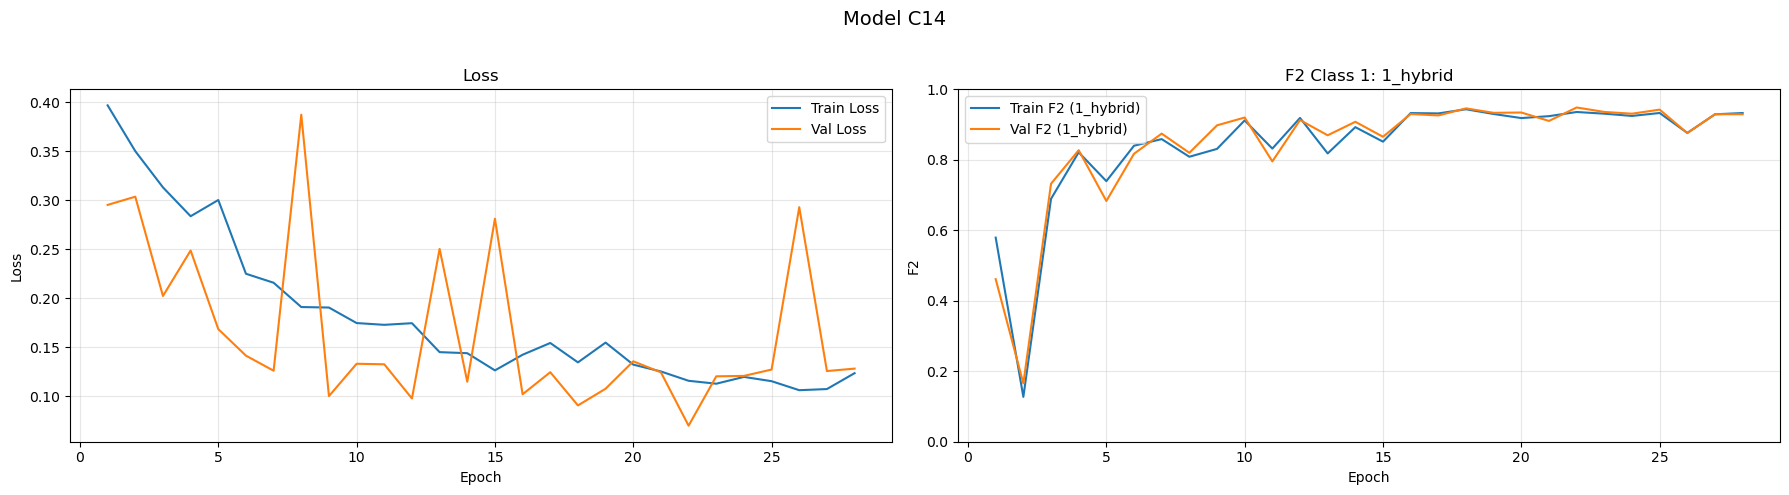

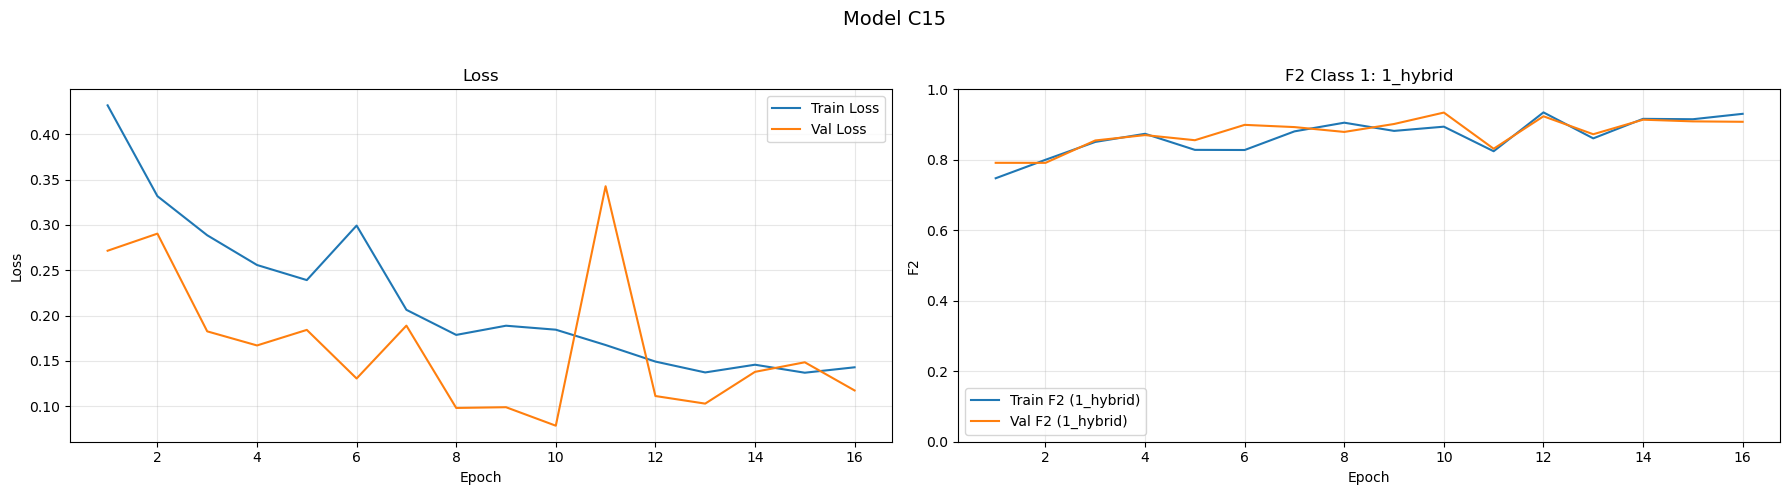

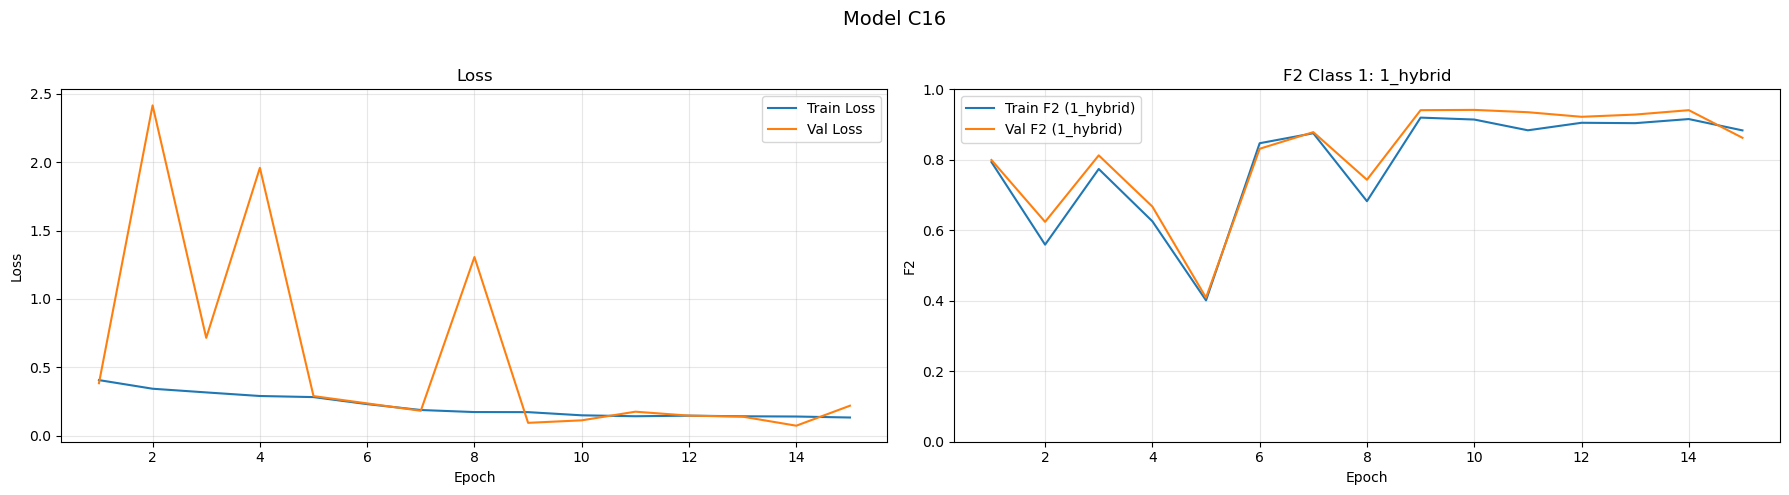

In [11]:
for i in range(1, 17):
    plot_training_curves(model_name=f"Model C{i}", results=results_from_ckpt(model=model_resnet_c_dict[f"model_resnet_c{i}"], ckpt_file=f"../../saved_models/resnet/resnet_c/resnet_model_c{i}_log.pkl"), class_idx=1, class_name="1_hybrid")